In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 리눅스 나눔 폰트 직접 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False



# tensorflow import mnist

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, X_test.shape

I0000 00:00:1774915924.371779    4243 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774915924.407594    4243 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774915925.301923    4243 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


((60000, 28, 28), (10000, 28, 28))

In [3]:
type(X_train)

numpy.ndarray

In [4]:
#픽셀값 정규화
X_train = X_train.reshape(-1, 28, 28, 1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# 합성곱 신경망의 구조  

In [5]:
from tensorflow.keras import Sequential, layers
model = Sequential(
  [
    layers.Input(shape=(28,28,1)), #3차원 이미지 1장의 입력
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'), #분류 계층
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
  ])
model.summary()

I0000 00:00:1774915935.692863    4243 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# 모델

In [6]:
model.layers[0].get_weights() #초기값 (랜덤)

[array([[[[ 0.00943871,  0.13696112,  0.06560315,  0.0055992 ,
            0.12661685,  0.08003932,  0.05627918, -0.02959117,
            0.07193188,  0.1172855 ,  0.02229862,  0.03304334,
           -0.00992452, -0.12937255,  0.07938872,  0.11132498,
            0.0225137 , -0.08324049, -0.05669214,  0.05910112,
            0.04086465,  0.09693675,  0.02367993,  0.00073102,
            0.02752835,  0.00435106,  0.06352612,  0.1393721 ,
            0.0442204 ,  0.12682031,  0.0947566 ,  0.02254976]],
 
         [[-0.06622271,  0.02937205,  0.11314718, -0.08710565,
           -0.09518111, -0.09842888,  0.01547012, -0.01421699,
           -0.12021813,  0.04060318, -0.12715788,  0.12708826,
            0.08080731, -0.12576067, -0.11953577,  0.02153446,
            0.12138082,  0.06808703, -0.10507214, -0.0648132 ,
           -0.04025928,  0.10129137,  0.0726041 ,  0.01420039,
           -0.00521469, -0.10713761,  0.03115152,  0.10205275,
            0.13572879, -0.13768701,  0.02473122,  

# 컴파일

In [7]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [8]:
history = model.fit(X_train, y_train, batch_size=128, epochs=10,
                        validation_split=0.2, #추가 
                      verbose=1)

Epoch 1/10


I0000 00:00:1774915952.651071    4531 service.cc:153] XLA service 0x79a9e0043900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774915952.651095    4531 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774915952.666149    4531 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774915952.776212    4531 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774915952.825383    4531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1791__.33


 16/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2100 - loss: 2.1737

I0000 00:00:1774915956.983606    4531 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8807 - loss: 0.3813 - val_accuracy: 0.9753 - val_loss: 0.0842
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9621 - loss: 0.1216 - val_accuracy: 0.9841 - val_loss: 0.0564
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9725 - loss: 0.0918 - val_accuracy: 0.9865 - val_loss: 0.0474
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.0762 - val_accuracy: 0.9879 - val_loss: 0.0409
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9796 - loss: 0.0655 - val_accuracy: 0.9893 - val_loss: 0.0370
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9825 - loss: 0.0584 - val_accuracy: 0.9893 - val_loss: 0.0380
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9838 - loss: 0.0535 - val_accuracy: 0.9903 - val_loss: 0.0349
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - loss: 0.0481 - val_accuracy: 0.9897 - val_

In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9925 - loss: 0.0240


# 시각화

In [10]:
import matplotlib.pyplot as plt
import numpy as np


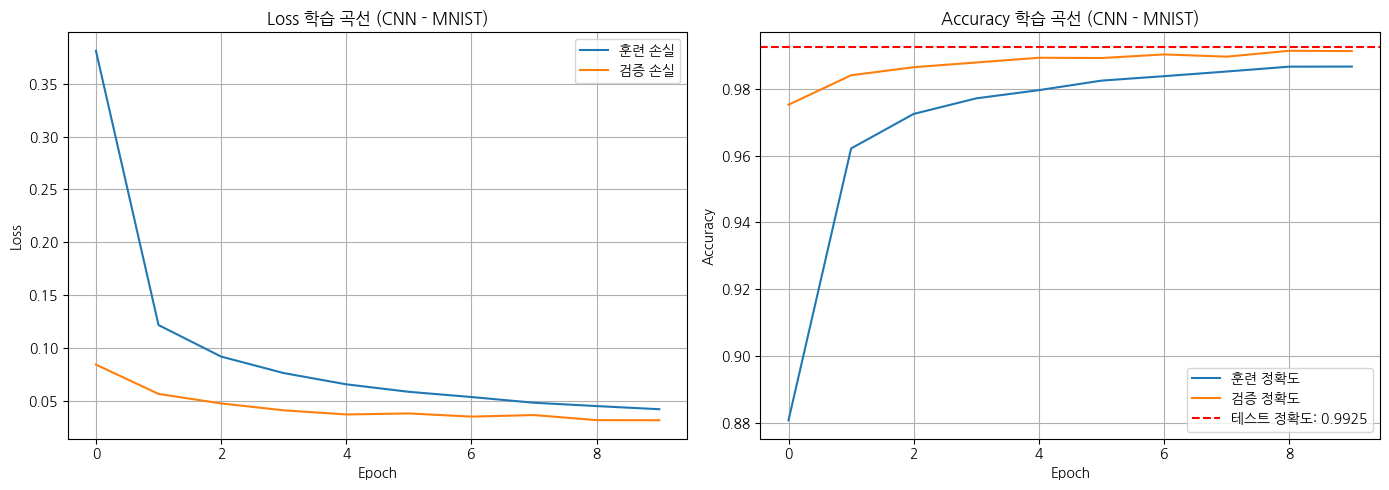

테스트 Loss    : 0.0240
테스트 Accuracy: 99.25%


In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선 (CNN - MNIST)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선 (CNN - MNIST)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# 테스트 정확도 기준선 추가
axes[1].axhline(y=acc, color='red', linestyle='--',
                label=f'테스트 정확도: {acc:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# 최종 결과 출력
print(f"테스트 Loss    : {loss:.4f}")
print(f"테스트 Accuracy: {acc*100:.2f}%")

# END

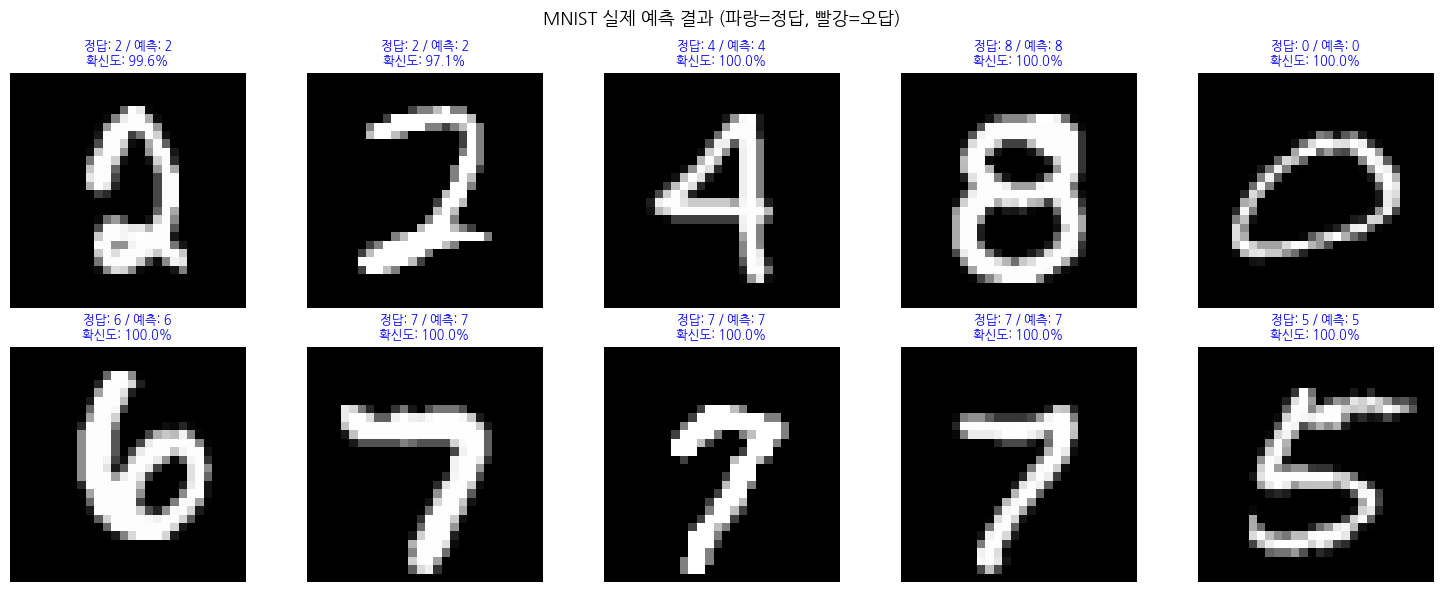

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 테스트 이미지 10개 랜덤 선택
indices = np.random.randint(0, len(X_test), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]

    # 예측
    pred_prob  = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    pred_label = np.argmax(pred_prob)
    confidence = pred_prob[0][pred_label] * 100

    # 시각화
    axes[i].imshow(img.reshape(28, 28), cmap='gray')
    axes[i].set_title(
        f'정답: {true_label} / 예측: {pred_label}\n확신도: {confidence:.1f}%',
        color='blue' if true_label == pred_label else 'red',
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('MNIST 실제 예측 결과 (파랑=정답, 빨강=오답)', fontsize=13)
plt.tight_layout()
plt.show()

# RESNET 전이학습

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [14]:
resnet_model = ResNet50(input_shape=(224, 224, 3), include_top=False)
resnet_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

# 이미지 로드

In [18]:
# ✅ 올바른 import 경로
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np

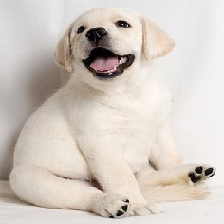

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[('n02099712', 'Labrador_retriever', np.float32(0.79146606)), ('n02099601', 'golden_retriever', np.float32(0.13169682)), ('n02104029', 'kuvasz', np.float32(0.040965494))]]


In [19]:
# 1. 이미지 로드
rab_img = image.load_img('YellowLabradorLooking_new.jpg', target_size=(224, 224))
display(rab_img) 

# 2. 배열 변환 + 차원 추가
X = np.expand_dims(image.img_to_array(rab_img), axis=0)
print(X.shape)  # (1, 224, 224, 3)

# 3. 전처리 → 예측
X = preprocess_input(X)
model = ResNet50(weights='imagenet')
preds = model.predict(X)
print(decode_predictions(preds, top=3))

In [17]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
import numpy as np

# 모델 로드
model = ResNet50(weights='imagenet')

# 이미지 로드 및 전처리
img = image.load_img('YellowLabradorLooking_new.jpg', target_size=(224, 224))
X = image.img_to_array(img)          # shape: (224, 224, 3)
X = np.expand_dims(X, axis=0)        # shape: (1, 224, 224, 3)
X = preprocess_input(X)              # ResNet50 전용 정규화

# 예측
pred = model.predict(X, verbose=0)
print('Predicted:', decode_predictions(pred, top=3))

Predicted: [[('n02099712', 'Labrador_retriever', np.float32(0.79146606)), ('n02099601', 'golden_retriever', np.float32(0.13169682)), ('n02104029', 'kuvasz', np.float32(0.040965494))]]


In [20]:
X = np.expand_dims(image.img_to_array(rab_img), axis=0)
X.shape

(1, 224, 224, 3)

# 추론 ResNet Model

In [21]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
import numpy as np

# 모델 로드
resnet_model = ResNet50(weights='imagenet')

# 이미지 로드 및 전처리
rab_img = image.load_img('YellowLabradorLooking_new.jpg', target_size=(224, 224))
X = np.expand_dims(image.img_to_array(rab_img), axis=0)
X = preprocess_input(X)

# 추론
pred = resnet_model.predict(X)
print('Predicted:', decode_predictions(pred, top=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: [[('n02099712', 'Labrador_retriever', np.float32(0.79146606)), ('n02099601', 'golden_retriever', np.float32(0.13169682)), ('n02104029', 'kuvasz', np.float32(0.040965494))]]


In [22]:
# decode_predictions는 이미 상단에서 import 완료된 상태
result = decode_predictions(pred, top=3)

for _, label, score in result[0]:
    print(f'{label}: {score:.4f}')


# 출력 예시:
#Labrador_retriever: 0.9123
# golden_retriever: 0.0421
# kuvasz: 0.0187

Labrador_retriever: 0.7915
golden_retriever: 0.1317
kuvasz: 0.0410


#  전이 학습

In [23]:
resnet_model_tl = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
resnet_model_tl.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

# 전이학습모델

In [24]:
resnet_model_tl.trainable = True

# 전이학습모델
model = Sequential()
model.add(resnet_model_tl)
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,352,259 (482.00 MB)

 Trainable params: 126,299,139 (481.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

# zipfile

In [25]:
import zipfile
zip_file_path = 'glaucoma.zip' #압축파일

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('./datasets/')

# Train_gen_data

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_gen = ImageDataGenerator(
  rotation_range=20,
  width_shift_range=0.2,
  height_shift_range=0.2,
  horizontal_flip=True,
)
train_gen_data = train_gen.flow_from_directory(
    './datasets/glaucoma/train', target_size=(224, 224), batch_size=32, class_mode='sparse'
)

Found 1394 images belonging to 3 classes.


# Test Data

In [27]:
test_gen = ImageDataGenerator()
test_data = test_gen.flow_from_directory(
    './datasets/glaucoma/test', target_size=(224, 224), batch_size=32, class_mode='sparse'
)

Found 150 images belonging to 3 classes.


In [28]:
train_gen_data.image_shape, test_data.image_shape 

((224, 224, 3), (224, 224, 3))

# 모델 설정


In [29]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [30]:
# 모델 전이학습
model.fit(
  train_gen_data, validation_data=test_data, epochs=20, verbose=1  
)

Epoch 1/20


I0000 00:00:1774916394.079692    4243 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1774916416.673393    4531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_84341__.391


 8/44 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.5088 - loss: 40.2239

I0000 00:00:1774916443.215549    4529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_84341__.391


44/44 ━━━━━━━━━━━━━━━━━━━━ 83s 885ms/step - accuracy: 0.6693 - loss: 8.5061 - val_accuracy: 0.5267 - val_loss: 145.9373
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.7131 - loss: 1.1358 - val_accuracy: 0.5867 - val_loss: 2.6595
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.7116 - loss: 0.9691 - val_accuracy: 0.6533 - val_loss: 109.3220
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.7238 - loss: 0.6312 - val_accuracy: 0.6333 - val_loss: 0.9179
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 277ms/step - accuracy: 0.7367 - loss: 0.5863 - val_accuracy: 0.7067 - val_loss: 0.6087
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 0.7468 - loss: 0.5782 - val_accuracy: 0.7000 - val_loss: 0.5938
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.7633 - loss: 0.5286 - val_accuracy: 0.7067 - val_loss: 0.5777
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accuracy: 0.7762 - loss: 0.5130 - val_accuracy: 0.7400

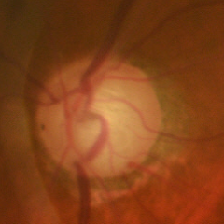

In [31]:
from tensorflow.keras.preprocessing import image
grau_img = image.load_img('test.png', target_size=(224, 224))
grau_img

In [32]:
X = np.expand_dims(image.img_to_array(grau_img), axis=0) 


In [33]:
pred = model.predict(X, verbose=0)
pred


array([[0.19438876, 0.8007608 , 0.00485044]], dtype=float32)